## Libaries 

In [1]:
import numpy as np
import math
import scipy.stats as stats
import matplotlib.pyplot as plt

# N-period Binomial Model

$$\text{European Call}$$

$$V_0=\frac{1}{1+r}^N\displaystyle\sum_{k=0}^{N}\binom{N}{k}(S_0u^kd^{N-k}-K)^+\tilde{p}^k(1-\tilde{p})^{N-k}$$

$\tilde{p}=\frac{1+r-d}{u-d}$

$$S_0=\text{initial price, }r=\text{interest rate, }u=\text{up factor, }d=\text{down factor, }N=\text{number of periods, }k=\text{number of +, }\tilde{p}=\text{up factor probability, }K=\text{strike price}$$

In [2]:
def binomial_call(S0, r, u, d, N, p_tilde, K):
    p_tilde = (1 + r - d) / (u - d)
    k = np.arange(N + 1)
    payoff = np.maximum(S0 * (u**k) * (d**(N - k)) - K, 0)
    prob = math.comb(N, k) * (p_tilde**k) * (1 - p_tilde)**(N - k)
    return np.sum(prob * payoff) / (1 + r)**N

$$\text{European Put}$$

$$V_0=\frac{1}{1+r}^N\displaystyle\sum_{k=0}^{N}\binom{N}{k}(K - S_0u^kd^{N-k})^+\tilde{p}^k(1-\tilde{p})^{N-k}$$

$\tilde{p}=\frac{1+r-d}{u-d}$

$$S_0=\text{initial price, }r=\text{interest rate, }u=\text{up factor, }d=\text{down factor, }N=\text{number of periods, }k=\text{number of +, }\tilde{p}=\text{up factor probability, }K=\text{strike price}$$

In [3]:
def binomial_put(S0, r, u, d, N, p_tilde, K):
    p_tilde = (1 + r - d) / (u - d)
    k = np.arange(N + 1)
    payoff = np.maximum(K - S0 * (u**k) * (d**(N - k)), 0)
    prob = math.comb(N, k) * (p_tilde**k) * (1 - p_tilde)**(N - k)
    return np.sum(prob * payoff) / (1 + r)**N

# Black Scholes Model (BS)


In [4]:
S0 = 17.6
r = 0.0393
K = 23
T = 0.5
sigma = 0.686

$$\text{European Call}$$

$$C_0^{BS}=S_0\Phi(d_1)-Ke^{-rT}\Phi(d_2)$$

$d_1=\frac{\log(\frac{S_0}{K})+(r+\frac{\sigma^2}{2})T}{\sigma\sqrt{T}}$

$d_2=d_1-\sigma\sqrt{T}$

$$S_0=\text{initial price, }r=\text{interest rate, }K=\text{strike price, }\sigma=\text{implied volatility}$$

In [5]:
def BS_call(S0, r, K, T, sigma):
    d1 = (np.log(S0 / K) + (r + (sigma**2) / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - (sigma * np.sqrt(T))
    V0 = (S0 * stats.norm.cdf(d1)) - (K * np.exp(-r * T) * stats.norm.cdf(d2))
    return V0

In [6]:
call_premium = BS_call(S0 = S0, r = r, K = K, T = T, sigma = sigma)
print(f"RIVN 6-month European Call, $23 strike price: ${call_premium:,.2f}")

RIVN 6-month European Call, $23 strike price: $1.85


In [7]:
def total_cash_call(call_premium, contracts_quanity = 1):
    cost = call_premium * 100 * contracts_quanity
    return cost

In [8]:
cost = total_cash_call(call_premium)
print(f"Total cost: ${cost:,.2f}")

Total cost: $185.04


$$\text{European Put}$$

$$P_0^{BS}=Ke^{-rT}\Phi(-d_2)-S_0\Phi(-d_1)$$

$d_1=\frac{\log(\frac{S_0}{K})+(r+\frac{\sigma^2}{2})T}{\sigma\sqrt{T}}$

$d_2=d_1-\sigma\sqrt{T}$

#### **Variables**
$S_0=\text{initial price, r}=\text{interest rate, K}=\text{strike price, }\sigma=\text{implied volatility}$

In [9]:
def BS_put(S0, r, K, T, sigma):
    d1 = (np.log(S0 / K) + (r + (sigma**2) / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - (sigma * np.sqrt(T))
    V0 = (K * np.exp(-r * T) * stats.norm.cdf(-d2)) - (S0 * stats.norm.cdf(-d1))
    return V0

In [10]:
put_premium = BS_put(S0 = S0, r = r, K = K, T = T, sigma = sigma)
print(f"RIVN 6-month European Put, $23 strike price: ${put_premium:,.2f}")

RIVN 6-month European Put, $23 strike price: $6.80


In [11]:
def total_cash_put(put_premium, contracts_quanity = 1):
    cost = put_premium * 100 * contracts_quanity
    return cost

In [12]:
cost = total_cash_put(put_premium)
print(f"Total cost of contract(s): ${cost:,.2f}")

Total cost of contract(s): $680.29


In [13]:
size = 1000
N = 1000000
z_score = np.random.standard_normal([size, N])
ST = S0 * np.exp((r - (sigma**2)/2) * T + sigma * np.sqrt(T) * z_score)

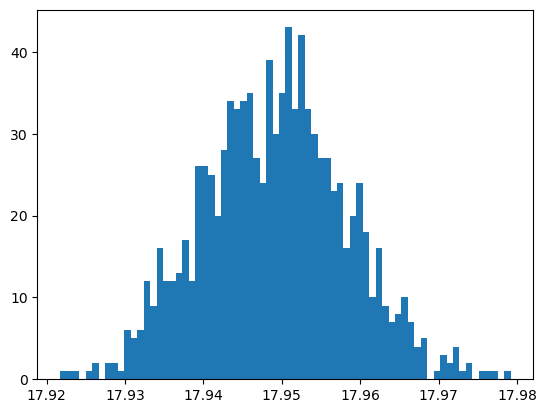

In [14]:
sample_means = np.mean(ST, axis = 1)
plt.hist(sample_means, bins = 70);

In [15]:
ST_mean = np.mean(sample_means)
ST_discounted = ST_mean/((1 + r)**T)
print(ST_mean)
print(ST_discounted)
print(S0 == ST_discounted)

17.949161100766155
17.606526791090655
False


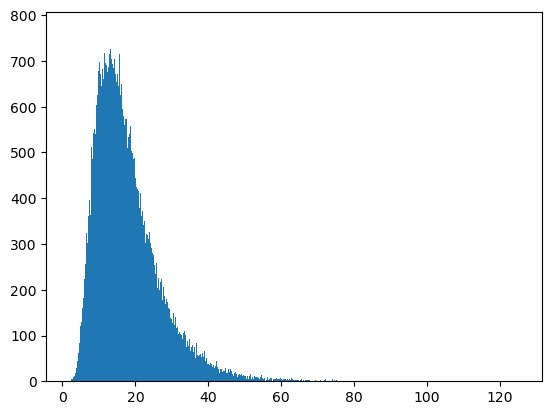

In [45]:
size2 = 100000
mean_log = np.log(S0) + (r - (sigma**2)/2) * T
std_log  = sigma * np.sqrt(T) 
St = np.random.lognormal(mean_log, std_log, size = size2)
plt.hist(St, bins = 1000);


In [49]:
print(np.mean(St > S0*2))
print(np.mean(St < S0/2))

0.05186
0.11047
